In [1]:
import sys
print(sys.executable)

c:\Users\ABUTHAHIR\anaconda3\python.exe


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Current working directory:")
print(os.getcwd())

DATA_DIR = Path("../../data/raw/extracted")

csv_files = list(DATA_DIR.rglob("*.csv"))

print(f"Data folder exists: {DATA_DIR.exists()}")
print(f"Total CSV files found: {len(csv_files)}")

Current working directory:
d:\CBL\CBL_17_London\src\src
Data folder exists: True
Total CSV files found: 4509


In [6]:
file_inventory = []

for file in csv_files:
    parts = file.name.replace(".csv", "").split("-")
    
    # Example file:
    # 2023-04-avon-and-somerset-street.csv
    
    month = "-".join(parts[0:2])
    data_type = parts[-1]
    force = "-".join(parts[2:-1])
    
    file_inventory.append({
        "file_path": str(file),
        "file_name": file.name,
        "month": month,
        "force": force,
        "data_type": data_type,
        "file_size_mb": file.stat().st_size / (1024 * 1024)
    })

inventory_df = pd.DataFrame(file_inventory)

inventory_df.head()

,file_path,file_name,month,force,data_type,file_size_mb
0,..\..\data\raw\extracted\2023-04\2023-04-avon-...,2023-04-avon-and-somerset-outcomes.csv,2023-04,avon-and-somerset,outcomes,0.615238
1,..\..\data\raw\extracted\2023-04\2023-04-avon-...,2023-04-avon-and-somerset-stop-and-search.csv,2023-04,avon-and-somerset-stop-and,search,0.129535
2,..\..\data\raw\extracted\2023-04\2023-04-avon-...,2023-04-avon-and-somerset-street.csv,2023-04,avon-and-somerset,street,3.131654
3,..\..\data\raw\extracted\2023-04\2023-04-bedfo...,2023-04-bedfordshire-outcomes.csv,2023-04,bedfordshire,outcomes,0.502040
4,..\..\data\raw\extracted\2023-04\2023-04-bedfo...,2023-04-bedfordshire-stop-and-search.csv,2023-04,bedfordshire-stop-and,search,0.076344


In [7]:
print("Total files:", len(inventory_df))
print("Total size in MB:", round(inventory_df["file_size_mb"].sum(), 2))
print("Total size in GB:", round(inventory_df["file_size_mb"].sum() / 1024, 2))

inventory_df["data_type"].value_counts()

Total files: 4509
Total size in MB: 7252.09
Total size in GB: 7.08


data_type
street      1561
outcomes    1502
search      1446
Name: count, dtype: int64

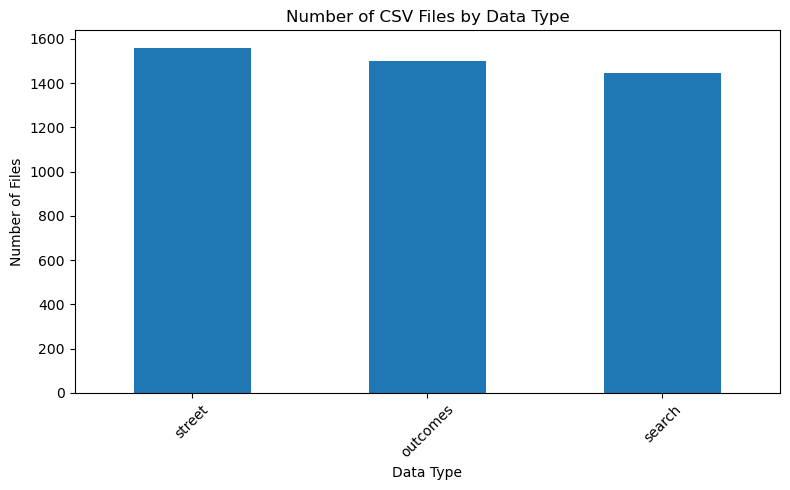

In [8]:
counts = inventory_df["data_type"].value_counts()

plt.figure(figsize=(8, 5))
counts.plot(kind="bar")
plt.title("Number of CSV Files by Data Type")
plt.xlabel("Data Type")
plt.ylabel("Number of Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

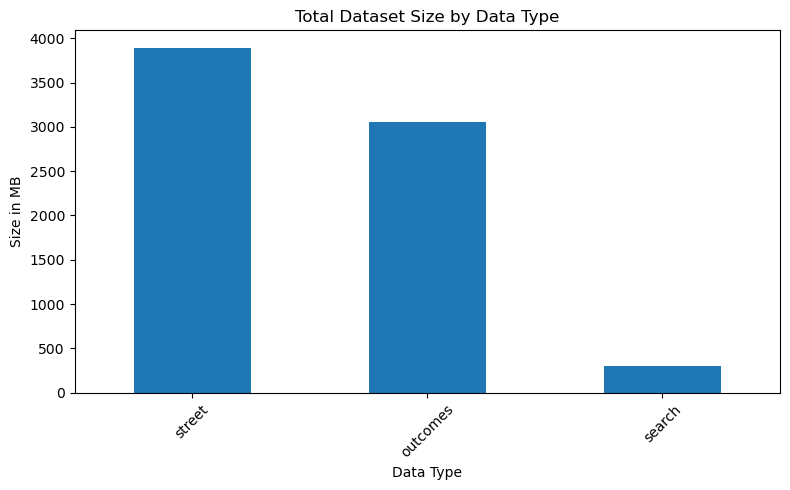

In [9]:
size_by_type = inventory_df.groupby("data_type")["file_size_mb"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
size_by_type.plot(kind="bar")
plt.title("Total Dataset Size by Data Type")
plt.xlabel("Data Type")
plt.ylabel("Size in MB")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

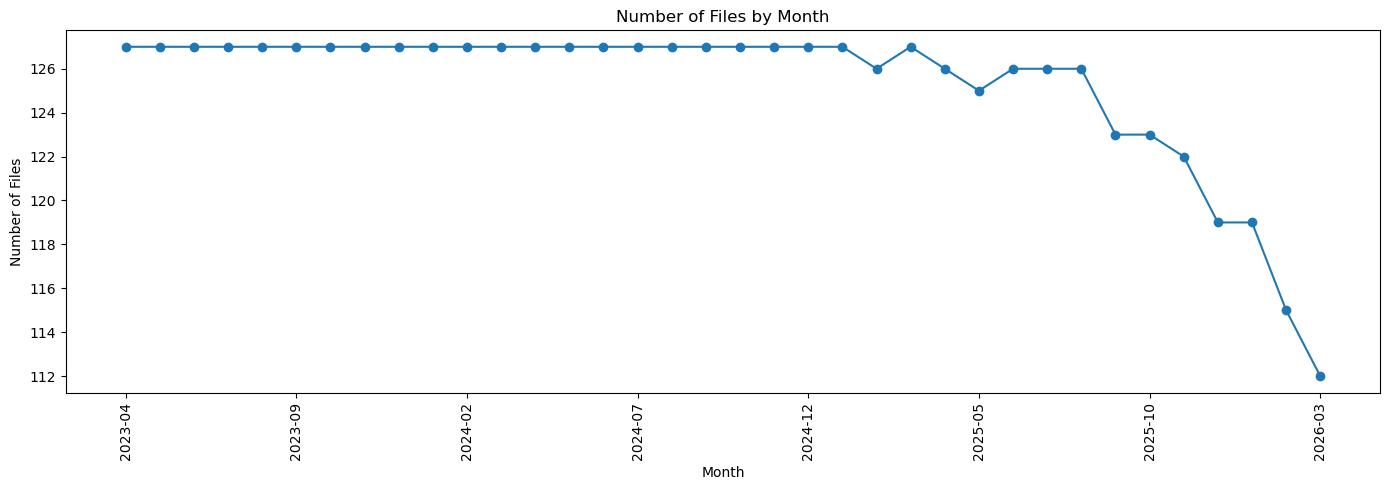

In [10]:
files_by_month = inventory_df["month"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
files_by_month.plot(kind="line", marker="o")
plt.title("Number of Files by Month")
plt.xlabel("Month")
plt.ylabel("Number of Files")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [11]:
column_records = []

for file in csv_files:
    try:
        sample = pd.read_csv(file, nrows=5, low_memory=False)
        column_records.append({
            "file_name": file.name,
            "file_path": str(file),
            "columns": tuple(sample.columns),
            "num_columns": len(sample.columns)
        })
    except Exception as e:
        column_records.append({
            "file_name": file.name,
            "file_path": str(file),
            "columns": None,
            "num_columns": None,
            "error": str(e)
        })

columns_df = pd.DataFrame(column_records)

columns_df.head()

KeyboardInterrupt: 

In [ ]:
column_structure_counts = columns_df["columns"].value_counts()

print(f"Number of unique column structures: {len(column_structure_counts)}")

column_structure_counts

In [ ]:
row_counts = []

for i, file in enumerate(csv_files, start=1):
    try:
        rows = sum(1 for _ in open(file, encoding="utf-8")) - 1
        row_counts.append({
            "file_name": file.name,
            "file_path": str(file),
            "rows": rows
        })
    except UnicodeDecodeError:
        rows = sum(1 for _ in open(file, encoding="latin1")) - 1
        row_counts.append({
            "file_name": file.name,
            "file_path": str(file),
            "rows": rows
        })
    except Exception as e:
        row_counts.append({
            "file_name": file.name,
            "file_path": str(file),
            "rows": None,
            "error": str(e)
        })
    
    if i % 250 == 0:
        print(f"Checked {i}/{len(csv_files)} files")

rows_df = pd.DataFrame(row_counts)

rows_df.head()

In [ ]:
eda_df = inventory_df.merge(
    rows_df[["file_name", "rows"]],
    on="file_name",
    how="left"
)

eda_df.head()

In [ ]:
total_rows = eda_df["rows"].sum()

print(f"Estimated total rows: {total_rows:,.0f}")

In [ ]:
rows_by_type = eda_df.groupby("data_type")["rows"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
rows_by_type.plot(kind="bar")
plt.title("Total Rows by Data Type")
plt.xlabel("Data Type")
plt.ylabel("Total Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
rows_by_month = eda_df.groupby("month")["rows"].sum().sort_index()

plt.figure(figsize=(14, 5))
rows_by_month.plot(kind="line", marker="o")
plt.title("Total Rows by Month")
plt.xlabel("Month")
plt.ylabel("Total Rows")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
sample_frames = []

for i, file in enumerate(csv_files, start=1):
    try:
        df_sample = pd.read_csv(file, nrows=1000, low_memory=False)
        df_sample["source_file"] = file.name
        sample_frames.append(df_sample)
    except Exception as e:
        print(f"Skipped {file.name}: {e}")
    
    if i % 250 == 0:
        print(f"Sampled {i}/{len(csv_files)} files")

sample_df = pd.concat(sample_frames, ignore_index=True, sort=False)

print(sample_df.shape)
sample_df.head()

In [ ]:
missing_percent = sample_df.isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
missing_percent.head(20).plot(kind="bar")
plt.title("Top 20 Columns by Missing Value Percentage")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
import pandas as pd

street_files = [file for file in csv_files if file.name.endswith("-street.csv")]

print(f"Number of street crime files found: {len(street_files)}")

crime_type_counter = Counter()
month_counter = Counter()
missing_counter = Counter()

total_rows = 0

columns_to_use = ["Month", "Crime type", "Longitude", "Latitude"]

for i, file in enumerate(street_files, start=1):
    try:
        for chunk in pd.read_csv(
            file,
            usecols=lambda col: col in columns_to_use,
            chunksize=100_000,
            low_memory=False
        ):
            rows = len(chunk)
            total_rows += rows

            crime_type_counter.update(chunk["Crime type"].dropna())
            month_counter.update(chunk["Month"].dropna())
            missing_counter.update(chunk.isna().sum().to_dict())

    except Exception as e:
        print(f"Skipped {file.name}: {e}")

    if i % 250 == 0:
        print(f"Processed {i}/{len(street_files)} street files")

print("Finished processing street crime files.")
print(f"Total street crime rows processed: {total_rows:,}")

In [ ]:
crime_counts = (
    pd.DataFrame(crime_type_counter.items(), columns=["Crime type", "Count"])
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

month_counts = (
    pd.DataFrame(month_counter.items(), columns=["Month", "Count"])
    .sort_values("Month")
    .reset_index(drop=True)
)

missing_df = (
    pd.DataFrame(missing_counter.items(), columns=["Column", "Missing count"])
    .sort_values("Missing count", ascending=False)
    .reset_index(drop=True)
)

missing_df["Missing percentage"] = (missing_df["Missing count"] / total_rows) * 100

display(crime_counts.head(20))
display(month_counts.head())
display(missing_df)

In [ ]:
crime_counts = street_df["Crime type"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
crime_counts.plot(kind="bar")
plt.title("Crime Type Distribution - Full Dataset")
plt.xlabel("Crime Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(crime_counts["Crime type"], crime_counts["Count"])
plt.title("Crime Type Distribution - Full Street Crime Dataset")
plt.xlabel("Crime Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(month_counts["Month"], month_counts["Count"], marker="o")
plt.title("Street Crime Records Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(missing_df["Column"], missing_df["Missing percentage"])
plt.title("Missing Values in Street Crime Data")
plt.xlabel("Column")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()